<b> Starbucks: </b> An Accounting-Based Valuation Using Python

By: Cesar Cepeda

## Table of Contents

- 📌 Section 1: Imports, Ticker Input, Data Pull
- 📌 Section 2: Historical Performance Summary
- 📌 Section 3: Historical Drivers / Ratio Analysis
- 📌 Section 4: Pro Forma Forecasting Block
- 📌 Section 5: Reverse-Engineered Valuation (Residual Income Growth)
- 📌 Section 6: Implied vs Analyst Growth Plot
- 📌 Section 7: Export Key Tables to Excel

Old HTML TOC Commented Out Below
<!-- 1. [Set Up](#set_up)
2. [At a Glance](#glance)
3. [Financial Statements](#fin_statements)
4. [Financial Statement Reformulation](#reformulation)
5. [Drivers](#drivers)
6. [Ratio Analysis](#ratios)
7. [Data Export to Excel](#export_xl)
8. [Pending](#pending) -->

# 📌 Section 1: Imports, Ticker Input, Data Pull

In [ ]:
# !pip install yfinance

In [1]:
# === Imports ===
# company financial data
import yfinance as yf

# Standard library imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

# Potentially optional imports
import requests
import statistics as st
import sys
import plotly.express as px
# import math

# === Global Display Setting Variables ===
pd.options.display.float_format = "{:,.2f}".format          # two decimals for numbers
np.set_printoptions(formatter = {'float':'{:,.2f}'.format}) # print options with numpy
pd.set_option("display.max_rows", 100)
plt.rcParams['figure.figsize'] = (8,8)                      # plot figure Size
plot_background = ['default', 'dark_background']            # plot bg color
# plt.style.use(plot_background[0])
plt.style.use("default")

In [ ]:
# # === Stored Financial Statements Dates ===
# income_stmt_date = dt.datetime(2025, 6, 25)
# balance_sheet_date = dt.datetime(2025, 6, 25)

In [ ]:
# === Ticker Selection ===
ticker = "SBUX"
company = yf.Ticker(ticker)

# === Applicable Dates for Repeat Output ===
info_date = dt.datetime(2025, 6, 21)
eps_date = dt.datetime(2025, 6, 21)

# === Stored Financial Statements Dates ===
income_stmt_date = dt.datetime(2025, 6, 25)
balance_sheet_date = dt.datetime(2025, 6, 25)

# === Adding in CFS Pull from yfinance here retroactively ===
cfs_date = dt.datetime(2025, 6, 28)

# === Cash Flow Statement ===
# cashflow_statement = company.cashflow.T
# timestamp = dt.datetime.now().strftime("%Y%m%d_%H%M")
timestamp = dt.datetime.now().strftime("%Y%m%d")

# 📌 Section 2: Historical Performance Summary

## === Get Company Info ===

In [3]:
# fast info 
company.fast_info
# detailed info
company.info

{'address1': '2401 Utah Avenue South',
 'city': 'Seattle',
 'state': 'WA',
 'zip': '98134',
 'country': 'United States',
 'phone': '206 447 1575',
 'website': 'https://www.starbucks.com',
 'industry': 'Restaurants',
 'industryKey': 'restaurants',
 'industryDisp': 'Restaurants',
 'sector': 'Consumer Cyclical',
 'sectorKey': 'consumer-cyclical',
 'sectorDisp': 'Consumer Cyclical',
 'longBusinessSummary': "Starbucks Corporation, together with its subsidiaries, operates as a roaster, marketer, and retailer of coffee worldwide. The company operates through three segments: North America, International, and Channel Development. Its stores offer coffee, tea, and other beverages, roasted whole beans and ground coffees, single serve products, and ready-to-drink beverages; and various food products, such as pastries, breakfast sandwiches, and lunch items. The company also licenses its trademarks through licensed stores, and grocery and foodservice accounts. The company offers its products under t

In [ ]:
# === DataFrame Creation From Company Ticker Information ===

# create DataFrames from fast_info and info dictionaries
fast_info_df = pd.DataFrame(company.fast_info.items(), columns=["Metric", "Value"])
detailed_info_df = pd.DataFrame(company.info.items(), columns=["Metric", "Value"])

# save both fast & detailed DataFrames to CSV Snapshots with date in filename
current_date = dt.datetime.now().strftime("%Y-%m-%d")

fast_info_df.to_csv(f"{ticker}_fast_info_{current_date}.csv", index=False)
detailed_info_df.to_csv(f"{ticker}_detailed_info_{current_date}.csv", index=False)

# --

# user input to load fast and detailed info from CSV Snapshots or from yfinance
load_from_csv = input("Use historical fast and detailed info? (y/n): ").strip().lower()

if load_from_csv == 'y':
    user_date = input("Enter date (YYYY-MM-DD) for historical CSV files you'd like to load: ").strip()
    fast_info_df = pd.read_csv(f"{ticker}_fast_info_{user_date}.csv")
    detailed_info_df = pd.read_csv(f"{ticker}_detailed_info_{user_date}.csv")
else:
    fast_info_df = pd.read_csv(f"{ticker}_fast_info_{current_date}.csv")
    detailed_info_df = pd.read_csv(f"{ticker}_detailed_info_{current_date}.csv")

# === Display DataFrames ===
print("\nFast Info DataFrame:")
print(fast_info_df)
print("\nDetailed Info DataFrame:")
print(detailed_info_df)


Fast Info DataFrame:
                        Metric                Value
0                     currency                  USD
1                      dayHigh    93.80000305175781
2                       dayLow     92.4000015258789
3                     exchange                  NMS
4              fiftyDayAverage    85.89540023803711
5                    lastPrice    93.12000274658203
6                   lastVolume              9196400
7                    marketCap   108005233695.70312
8                         open    93.08000183105469
9                previousClose                92.37
10                   quoteType               EQUITY
11  regularMarketPreviousClose    92.27999877929688
12                      shares           1159849984
13         tenDayAverageVolume              8148970
14     threeMonthAverageVolume             11326990
15                    timezone     America/New_York
16        twoHundredDayAverage    95.63015007019042
17                  yearChange  0.16794178

In [5]:
# === Create EPS Trend DataFrame ===
eps_trend = company.eps_trend
eps_trend_df = pd.DataFrame(eps_trend)
print(eps_trend_df)

# --

# save EPS trend DataFrame to CSV Snapshot with date in filename
eps_trend_df.to_csv(f"{ticker}_eps_trend_{current_date}.csv", index=False)

# --

# user input to eps trend from CSV Snapshots or from yfinance
eps_from_csv = input("Use historical eps trend info? (y/n): ").strip().lower()

if eps_from_csv == 'y':
    user_date_eps = input("Enter date (YYYY-MM-DD) for EPS trend CSV file you'd like to load: ").strip()
    eps_trend_df = pd.read_csv(f"{ticker}_eps_trend_{user_date_eps}.csv")    
else:
    eps_trend_df = pd.read_csv(f"{ticker}_eps_trend_{current_date}.csv")

# === Display EPS Trend DataFrame ===
print("\nEPS Trend DataFrame:")
print(eps_trend_df)

        current  7daysAgo  30daysAgo  60daysAgo  90daysAgo
period                                                    
0q         0.66      0.66       0.66       0.85       0.87
+1q        0.69      0.70       0.70       0.84       0.86
0y         2.46      2.46       2.46       2.50       2.94
+1y        2.98      2.99       3.03       3.11       3.64

EPS Trend DataFrame:
   current  7daysAgo  30daysAgo  60daysAgo  90daysAgo
0     0.66      0.66       0.67       0.86       0.87
1     0.70      0.69       0.70       0.85       0.87
2     2.48      2.46       2.48       2.92       2.95
3     3.02      3.02       3.06       3.59       3.65


## === Global Assumptions Required for Valuation ===

In [15]:
# == #1: Weighted Average Cost of Capital (WACC) ==
wacc = 0.07

In [7]:
# == #2: Analyst EPS ==

# Analyst EPS using company.info
eps1_info = round(float(detailed_info_df.loc[detailed_info_df['Metric'] == 'epsCurrentYear', 'Value'].values[0]),2)
print(f"\nTrailing EPS: {eps1_info}")
eps2_info = float(detailed_info_df.loc[detailed_info_df['Metric'] == 'forwardEps', 'Value'].values[0])
print(f"Forward EPS: {eps2_info}")
eps3_info = round(eps2_info * (1 + wacc),2)
print(f"Fwd EPS T+2: {eps3_info}")

# Analyst EPS using eps_trend_df
eps1_trend = round(eps_trend_df.loc[eps_trend_df.index == 2, 'current'].values[0],2)
print(f"\nEPS T+1 from trend: {eps1_trend}")
eps2_trend = round(eps_trend_df.loc[eps_trend_df.index == 3, 'current'].values[0],2)
print(f"EPS T+2 from trend: {eps2_trend}")
eps3_trend = round(eps2_trend * (1+wacc),2) # growing at wacc
print(f"EPS T+3 from trend: {eps3_trend}")

# Using More Conservative EPS
eps1 = min(eps1_info, eps1_trend)
print(f"\nFinal EPS T+1 (Conservative): {round(eps1,2)}")
eps2 = min(eps2_info, eps2_trend)
print(f"Final EPS T+2 (Conservative): {round(eps2,2)}")  
eps3 = min(eps3_info, eps3_trend)
print(f"Final EPS T+3 (Conservative): {round(eps3,2)}")


Trailing EPS: 2.48
Forward EPS: 3.72
Fwd EPS T+2: 3.98

EPS T+1 from trend: 2.48
EPS T+2 from trend: 3.02
EPS T+3 from trend: 3.23

Final EPS T+1 (Conservative): 2.48
Final EPS T+2 (Conservative): 3.02
Final EPS T+3 (Conservative): 3.23


In [8]:
# == #3: Payout Ratio Scenarios ==

# payout ratio from company info
payout_ratio = float(detailed_info_df.loc[detailed_info_df['Metric'] == 'payoutRatio', 'Value'].values[0])
print(f"Payout Ratio (Company Info): {payout_ratio:,.2%}")

# payout ratio from dividends and earnings
dividend_rate = float(detailed_info_df.loc[detailed_info_df['Metric'] == 'dividendRate', 'Value'].values[0])
print(f"\nDividend Rate (Company Info): {dividend_rate:,.2f}")

earnings_per_share = float(detailed_info_df.loc[detailed_info_df['Metric'] == 'trailingEps', 'Value'].values[0])
print(f"Earnings Per Share (EPS): {earnings_per_share:,.2f}")

payout_ratio_from_dividends = dividend_rate / earnings_per_share
print(f"Payout Ratio, Calculated (Dividend Rate / EPS): {payout_ratio_from_dividends:,.2%}")

# using the most conservative payout ratio
payout_ratio = min(payout_ratio, payout_ratio_from_dividends)
print(f"\nFinal Payout Ratio (Most Conservative): {payout_ratio:,.2%}")

# calculate dividends instead using payout and earnings
dividends = payout_ratio * earnings_per_share
print(f"\nDividend Rate, Calculated (Payout Ratio * EPS): {dividends:,.2f}")

Payout Ratio (Company Info): 85.82%

Dividend Rate (Company Info): 2.44
Earnings Per Share (EPS): 2.75
Payout Ratio, Calculated (Dividend Rate / EPS): 88.73%

Final Payout Ratio (Most Conservative): 85.82%

Dividend Rate, Calculated (Payout Ratio * EPS): 2.36


In [9]:
# == #4: *Starting* Book Value Per Share (BVPS) ==

# derived from company info
bvps_info = float(detailed_info_df.loc[detailed_info_df['Metric'] == 'bookValue', 'Value'].values[0])
print(f"\nBVPS from Company Info: {bvps_info:,.2f}")


# back-calculated from price to book ratio
price_to_book = float(detailed_info_df.loc[detailed_info_df['Metric'] == 'priceToBook', 'Value'].values[0])
print(f"\nPrice to Book (P2B) Ratio: {price_to_book:,.2f}")

share_price = float(fast_info_df.loc[fast_info_df['Metric'] == 'lastPrice', 'Value'].values[0])
print(f"Share Price: {share_price:,.2f}")

bvps_p2b = share_price / price_to_book
print(f"Share Price / P2B Ratio = BVPS from P2B Ratio: {bvps_p2b:,.2f}")


# Incomplete: Using Shareholders Equity as Proxy for Book Value
shares_outstanding = int(detailed_info_df.loc[detailed_info_df['Metric'] == 'sharesOutstanding', 'Value'].values[0])
print(f"\nShares Outstanding: {shares_outstanding:,}")
shareholders_equity = float(detailed_info_df.loc[detailed_info_df['Metric'] == 'bookValue', 'Value'].values[0]) * shares_outstanding
print(f"Shareholders Equity: {shareholders_equity:,.2f}")


# 4B: book value (T+1) calculation using eps and dividends
bvps1 = bvps_info + eps1 - dividends
print(f"\nBook Value Per Share T+1 (BVPS1) (BVPS0 + EPS1 - Dividends1): {bvps1:,.2f}")


BVPS from Company Info: -6.71

Price to Book (P2B) Ratio: -13.88
Share Price: 93.12
Share Price / P2B Ratio = BVPS from P2B Ratio: -6.71

Shares Outstanding: 1,136,400,000
Shareholders Equity: -7,624,107,600.00

Book Value Per Share T+1 (BVPS1) (BVPS0 + EPS1 - Dividends1): -6.59


In [10]:
# == #5: Growth Rate (EPS-Driven) ==

# From EPS Trend
growth_rate = (eps2 / eps1) - 1
print(f"Growth Rate from EPS Trend: {growth_rate:,.2%}")

# INCOMPLETE - G from other metrics

Growth Rate from EPS Trend: 21.77%


# 📌 Section 3: Pro Forma Forecasting Block

## === Assumptions Recap ===

In [11]:
print(f"""
EPS1 (T+1):     {eps1:.2f}
EPS2 (T+2):     {eps2:.2f}
EPS3 (T+3):     {eps3:.2f}
Payout Ratio:   {payout_ratio:.2%}
BVPS:           {bvps_info:.2f}     (actual, negative due to share buybacks)
BVPS1:          {bvps1:.2f}         (using eps / payout ratio equation)
Growth Rate:    {growth_rate:.2%}
WACC:           {wacc:.2%}
""")


EPS1 (T+1):     2.48
EPS2 (T+2):     3.02
EPS3 (T+3):     3.23
Payout Ratio:   85.82%
BVPS:           -6.71     (actual, negative due to share buybacks)
BVPS1:          -6.59         (using eps / payout ratio equation)
Growth Rate:    21.77%
WACC:           7.00%



## === 5-Year Forecast Table ===

In [12]:
# === 5-Year Forecast Table ===

# Set up forecast horizon
years = [1, 2, 3, 4, 5]

# Initialize lists
eps_list = [eps1, eps2, eps3]
dividends_list = []
bvps_list = [bvps1]  # already calculated T+1 BVPS

# Use conservative growth rate (already calculated)
g = growth_rate

# Forecast EPS for T+4 and T+5
eps4 = eps3 * (1 + g)
eps5 = eps4 * (1 + g)
eps_list += [eps4, eps5]

# Forecast loop: Dividends and BVPS
for t in range(5):
	eps = eps_list[t]
	dividends = payout_ratio * eps
	dividends_list.append(dividends)
	
	if t > 0:
		bvps = bvps_list[t-1] + eps - dividends
		bvps_list.append(bvps)

In [13]:
# Build DataFrame
forecast_df = pd.DataFrame({
    'Year': years,
    'EPS': eps_list,
    'Dividends': dividends_list,
    'BVPS': bvps_list
})

# Display the forecast DataFrame
forecast_df = forecast_df.set_index('Year')
print("\n5-Year Forecast DataFrame:")
print(forecast_df)


5-Year Forecast DataFrame:
      EPS  Dividends  BVPS
Year                      
1    2.48       2.13 -6.59
2    3.02       2.59 -6.16
3    3.23       2.77 -5.70
4    3.93       3.38 -5.15
5    4.79       4.11 -4.47


## === Residual Income Forecast ===

In [ ]:
# === Residual Income Forecast ===

# Inputs
# wacc
g = growth_rate  # EPS Growth Rate

ri_list = []
pv_ri_list = []

for t in range(5):
# for t in range(1,6):
    eps = forecast_df.iloc[t]['EPS']
    bv = forecast_df.iloc[t]['BVPS']
    ri = eps - (wacc * bv)
    ri_list.append(ri)

    # Present Value of RI
    discount_factor = (1 + wacc) ** (t + 1)
    pv_ri = ri / discount_factor
    pv_ri_list.append(pv_ri)

# Add RI to DataFrame
forecast_df['RI'] = [round(x, 2) for x in ri_list]
forecast_df['PV_RI'] = [round(x, 2) for x in pv_ri_list]


# Display the updated DataFrame with Residual Income
print("\n5-Year Forecast DataFrame with Residual Income:")
print(forecast_df)


5-Year Forecast DataFrame with Residual Income:
      EPS  Dividends  BVPS   RI  PV_RI
Year                                  
1    2.48       2.13 -6.59 2.94   2.75
2    3.02       2.59 -6.16 3.45   3.01
3    3.23       2.77 -5.70 3.63   2.96
4    3.93       3.38 -5.15 4.29   3.28
5    4.79       4.11 -4.47 5.10   3.64


In [17]:
# === Displaying Book Value Per Share (BVPS) Information ===
bvps_dict = {
    'BVPS from Company Info': bvps_info,
    'BVPS from P2B Ratio': bvps_p2b,
    'Shares Outstanding': shares_outstanding,
    'Shareholders Equity': shareholders_equity,
    'Book Value Per Share T+1 (BVPS1)': bvps1
}
print("\nBook Value Per Share (BVPS) Information:")
for key, value in bvps_dict.items():
    print(f"{key}: {value:,.2f}")


Book Value Per Share (BVPS) Information:
BVPS from Company Info: -6.71
BVPS from P2B Ratio: -6.71
Shares Outstanding: 1,136,400,000.00
Shareholders Equity: -7,624,107,600.00
Book Value Per Share T+1 (BVPS1): -6.59


In [31]:
# === Terminal Value ===
ri_5 = ri_list[-1]
ri_terminal = (ri_5 * (1 + g)) / (wacc - g)
pv_ri_terminal = ri_terminal / ((1 + wacc) ** 5)

# === Building the Value Block Summary ===
print("=== Value Block Summary ===")

# Setting Correct Starting BVPS
bv_start = bvps_info
print(f"Changing starting BVPS (Year 0) from: {forecast_df.iloc[0]['BVPS']:.2f} to: {bvps_info:.2f}")

total_pv_ri = sum(pv_ri_list)
total_value = bv_start + total_pv_ri + pv_ri_terminal

print(f"\n📊 Total Value Calculation:\nBV + PV(RI) + PV(Terminal RI) = \n{bv_start:.2f} + {total_pv_ri:.2f} + {pv_ri_terminal:.2f} = {total_value:.2f}")

=== Value Block Summary ===
Changing starting BVPS (Year 0) from: -6.59 to: -6.71

📊 Total Value Calculation:
BV + PV(RI) + PV(Terminal RI) = 
-6.71 + 15.64 + -29.98 = -21.05


In [32]:
# === Displaying the Forecast Table Output with Residual Income ===
print("\n📈 Residual Income Forecast Table")

forecast_df = forecast_df.reset_index()
print(forecast_df[['Year', 'EPS', 'BVPS', 'RI', 'PV_RI']])
# print(forecast_df[['EPS', 'BVPS', 'RI', 'PV_RI']])

print(f"\nTerminal RI Value (undiscounted): {ri_terminal:,.2f}")
print(f"PV of Terminal RI: {pv_ri_terminal:,.2f}")
print(f"\n📊 Final Valuation: BV + PV(RI) + PV(Terminal RI)\n= {bv_start:.2f} + {total_pv_ri:.2f} + {pv_ri_terminal:.2f} = {total_value:.2f}")


📈 Residual Income Forecast Table
   Year  EPS  BVPS   RI  PV_RI
0     1 2.48 -6.59 2.94   2.75
1     2 3.02 -6.16 3.45   3.01
2     3 3.23 -5.70 3.63   2.96
3     4 3.93 -5.15 4.29   3.28
4     5 4.79 -4.47 5.10   3.64

Terminal RI Value (undiscounted): -42.06
PV of Terminal RI: -29.98

📊 Final Valuation: BV + PV(RI) + PV(Terminal RI)
= -6.71 + 15.64 + -29.98 = -21.05


# 📌 Section 4: Reverse-Engineered Valuation (Residual Income Growth)

## === Redoing RI/TV Calcs after Solving ga=gb ===

1. Solve for g that solves this equation:
![PriceEqn](../data/price_equation.png)

2. using markdown syntax:
$$
P_0 = BV_0 + \sum_{t=1}^5 \frac{RI_t}{(1 + r)^t} + \frac{RI_5 \cdot (1 + g)}{(r - g) \cdot (1 + r)^5}
$$

3. using image renderer:

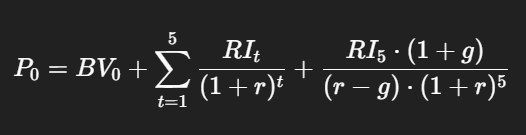

In [34]:
from IPython.display import Image
Image(filename='../data/price_equation.png')

In [40]:
from scipy.optimize import fsolve

# Inputs
print("=== Implied g Inputs===")
current_price = share_price  # Replace with actual market price
# current_price = 98.50  # Replace with actual market price

bv_start = bvps_info  # Ensure this is BV0, not from the DataFrame
ri_5 = ri_list[-1]     # RI in Year 5

print(f"Current Price: {current_price:.2f}, \nBV Start: {bv_start:.2f}, \nRI in Year 5: {ri_5:.2f}")

=== Implied g Inputs===
Current Price: 93.12, 
BV Start: -6.71, 
RI in Year 5: 5.10


In [41]:
# Step 1: Define the function that zeroes out at the correct g
def solve_for_g(g_guess):
    if g_guess >= wacc:  # Avoid divide-by-zero or negative denominator
        return 1e6  # arbitrarily high error
    ri_terminal = ri_5 * (1 + g_guess) / (wacc - g_guess)
    pv_terminal = ri_terminal / ((1 + wacc) ** 5)
    value = bv_start + sum(pv_ri_list) + pv_terminal
    return value - current_price

# Step 2: Run Solver
implied_g = fsolve(solve_for_g, 0.02)[0]
print(f"\n📈 Implied Long-Term Growth Rate (ga = gb) = {implied_g:.2%}")


📈 Implied Long-Term Growth Rate (ga = gb) = 2.57%


In [43]:
# Optional: use this new g to recompute terminal RI and total value
ri_terminal_new = ri_5 * (1 + implied_g) / (wacc - implied_g)
pv_terminal_new = ri_terminal_new / ((1 + wacc) ** 5)
total_value_new = bv_start + sum(pv_ri_list) + pv_terminal_new

print(f"📊 Updated Terminal RI Value (undiscounted) = {ri_terminal_new:.2f}")
print(f"📉 PV of Terminal RI = {pv_terminal_new:.2f}")
print(f"💰 Implied Intrinsic Value = {total_value_new:.2f}")

print(f"\n📊 Final Valuation (3 Building Blocks Implied by Market Price):\nBV + PV(RI) + PV(Terminal RI)_new \n = {bv_start:.2f} + {total_pv_ri:.2f} + {pv_terminal_new:.2f} = {total_value_new:.2f}")

📊 Updated Terminal RI Value (undiscounted) = 118.08
📉 PV of Terminal RI = 84.19
💰 Implied Intrinsic Value = 93.12

📊 Final Valuation (3 Building Blocks Implied by Market Price):
BV + PV(RI) + PV(Terminal RI)_new 
 = -6.71 + 15.64 + 84.19 = 93.12


## === Sensitivity Matrix (WACC x g) ===

In [44]:
# Define ranges
wacc_values = [0.07, 0.08, 0.09]
g_values = [implied_g - 0.005, implied_g, implied_g + 0.005]

# Store results
sensitivity_matrix = pd.DataFrame(index=[f"{g*100:.2f}%" for g in g_values],
                                    columns=[f"{w*100:.2f}%" for w in wacc_values])

# Loop over combinations
for g in g_values:
    for w in wacc_values:
        # Recalculate terminal RI and PV with new g and wacc
        ri_terminal = ri_5 * (1 + g) / (w - g)
        pv_terminal = ri_terminal / ((1 + w) ** 5)
        intrinsic_value = bv_start + sum(pv_ri_list) + pv_terminal
        sensitivity_matrix.loc[f"{g*100:.2f}%", f"{w*100:.2f}%"] = round(intrinsic_value, 2)

print ("\n📊 Sensitivity Analysis Matrix:")
print(sensitivity_matrix)


📊 Sensitivity Analysis Matrix:
       7.00% 8.00% 9.00%
2.07%  84.22 68.68 57.76
2.57%  93.12 74.50 61.81
3.07% 104.29 81.50 66.55


# 📌 Section 5: Historical Driver Decomposition (7/8/25)

## === Agenda ===
---
 1. Imports
 2. Rebuild NOPAT & NOA (Exact Line Items)
 3. L1: ROCE Decomposition
 4. L2: RNOA Decomposition
 5. L3: Individual PM & ATO Ratios

## === Load Variables, Financial Statements ===

In [55]:
# === Reprinting Date and Time Variables Used for File Naming ===
print("=== Dates and Times Used for File Naming ===")
print(f"Info Date: {info_date.strftime('%Y-%m-%d')}")
print(f"EPS Date: {eps_date.strftime('%Y-%m-%d')}\n")

print(f"Income Stmt Date: {income_stmt_date.strftime('%Y-%m-%d')}")
print(f"Balance Sheet Date: {balance_sheet_date.strftime('%Y-%m-%d')}")
print(f"CFS Date: {cfs_date.strftime('%Y-%m-%d')}")

# === Timestamp for File Naming ===
print(f"\n=== Timestamp for File Naming ===")
print(f"Timestamp: {timestamp}")

=== Dates and Times Used for File Naming ===
Info Date: 2025-06-21
EPS Date: 2025-06-21

Income Stmt Date: 2025-06-25
Balance Sheet Date: 2025-06-25
CFS Date: 2025-06-28

=== Timestamp for File Naming ===
Timestamp: 20250718_1759


In [ ]:
# == New User Input to Load Financial Statements [a/o 7/18/25] GPT-Assisted ===
# === User Input to Load Financial Statements ===

# --- Income Statement (IS) ---
load_is = input("Use historical income statement? (y/n): ").strip().lower()
if load_is == "y":
    # display existing date
    default_date = income_stmt_date.strftime("%Y-%m-%d")
    # print(f"Current date for historical financials is {default_date}")
    use_default = input(f"Use this date for the income statement? {default_date} (y/n): ").strip().lower()
    if use_default == "y":
        date_is = default_date
    else:
        date_is = input("Enter date (YYYY-MM-DD) for income statement file: ").strip()
    income_stmt = pd.read_csv(f"{ticker}_income_statement_{date_is}.csv",
                                      index_col=0   )
else:
    # fall back to the timestamped snapshot
    income_stmt = pd.read_csv(f"{ticker}_income_statement_{timestamp}.csv",
                              index_col=0   )

# --- Balance Sheet (BS) ---
load_bs = input("Use historical balance sheet? (y/n): ").strip().lower()
if load_bs == "y":
    # display existing date
    default_date = balance_sheet_date.strftime("%Y-%m-%d")
    use_default = input(f"Use this date for the balance sheet? {default_date} (y/n): ").strip().lower()
    if use_default == "y":
        date_bs = default_date
    else:
        date_bs = input("Enter date (YYYY-MM-DD) for balance sheet file: ").strip()
    balance_sheet = pd.read_csv(f"{ticker}_balance_sheet_{date_bs}.csv",
                                index_col=0 )
else:
    # fall back to the timestamped snapshot
    balance_sheet = pd.read_csv(f"{ticker}_balance_sheet_{timestamp}.csv",
                                index_col=0 )

# --- Cash Flow Statement (CFS) ---
load_cfs = input("Use historical cash flow statement? (y/n): ").strip().lower()
if load_cfs == "y":
    # display existing date
    default_date = cfs_date.strftime("%Y-%m-%d")    
    use_default = input(f"Use this date for the cash flow statement? {default_date} (y/n): ").strip().lower()
    if use_default == "y":
        date_cfs = default_date
    else:
        date_cfs = input("Enter date (YYYY-MM-DD) for cash flow file: ").strip()
    cashflow_statement = pd.read_csv(f"{ticker}_cashflow_statement_{date_cfs}.csv",
                                     index_col=0    )
else:
    # fall back to the timestamped snapshot
    cashflow_statement = pd.read_csv(f"{ticker}_cashflow_statement_{timestamp}.csv",
                                     index_col=0)

In [59]:
# === Miscellaneous ===
# MISC. Helper functions: enumerate and cash flow pull from yfinance
## 5. Helper to enumerate columns
def list_columns(df: pd.DataFrame):
    for idx, col in enumerate(df.columns):
        print(idx, col)

## === Terms and Definitions ===

### 📊 Core Variables:
- Revenue               : top-line sales
- Net Income            : after-tax earnings
- Tax Rate              : effective rate used in modeling
- Operating Revenue     : helpful for calculating margins
- Gross Profit & CoR    : to assess profitability
- Book Value            : shareholder equity (negative, as expected for SBUX due to share repurchases)
- Shares Outstanding    : needed to compute per-share values

--

### 🗺️ Mapping to Column Names in Financial Statements (PENDING)

--

### Ratios (PENDING)
- 📊 NOPAT:
  $$
      NOPAT_Traditional=Operating Income×(1−Effective Tax Rate)
  $$

  $$
      NOPAT_Exact=(Net Interest Income × (1 – Tax Rate) – Minority Interests) + Net Income Common Stockholders
  $$

## === NOPAT & NOA ===
Rebuilding from exact line items

In [ ]:
# === Recreate NOPAT and NOA exactly as in your historical code ===

# 1️⃣ (TRADITIONAL) NOPAT (less exact) as Operating Income * (1 - EFFECTIVE Tax Rate)
# NOPAT = Operating Income×(1−Effective Tax Rate)

# 1️⃣ (EXACT) NOPAT exactly as NFE + NetIncome
# NOPAT = (Net Interest Income × (1 – Tax Rate) – Minority Interests) + Net Income Common Stockholders

# nfe = (inc["Net Interest Income"] * (1 - inc["Tax Rate For Calcs"]) - inc["Minority Interests"])
# nopat = nfe + inc["Net Income Common Stockholders"]

# 2️⃣ NOA from explicit BS line items
# NOA   = Operating Assets – Operating Liabilities, where:

# Operating Assets = 
# Cash & Cash Equivalents + Short Term Investments
# + Receivables + Inventory + Prepaids + Other Current Assets
# + Net PPE + Other Non-Current Assets – Goodwill & Intangibles?
# if you want to exclude goodwill/intangibles, don’t add them here

# Operating Liabilities = 
# Accounts Payable + Accrued Expenses + Current Provisions
# + Deferred Revenue + Other Curr Liab
# + (exclude debt)
# add any other trade/operating liab you had historically

## 🔹Historical Decomposition (Streamlined 7/8-7/9 2025)

In [60]:
# === SMART FUZZY MATCHING COLUMN MAPPER 7/9/25 ===

# (fuzzy match import)
import difflib

# function to fuzzy match column names
def map_column(df, desired, n=5, cutoff=0.6):
    """Find the best match for `desired` among df.columns."""
    cols = df.columns.tolist()
    
    if desired in cols:
        return desired
    
    matches = difflib.get_close_matches(desired, cols, n=n, cutoff=cutoff)
    
    if not matches:
        raise KeyError(f"No close match found for '{desired}'")
    
    print(f"\nColumn matches for '{desired}':")
    
    for i, m in enumerate(matches, 1):
        print(f"  {i}. {m}")
    
    choice = input(f"Choose the number of the column for '{desired}': ").strip()
    
    return matches[int(choice) - 1]

In [61]:
# 1) Reload your statements
inc = company.financials.T.copy()
bs  = company.balance_sheet.T.copy()

In [62]:
# 2) Map the few columns you need
tax_col    = map_column(inc, "Tax Rate For Calcs")
opinc_col  = map_column(inc, "Operating Income")
netni_col  = map_column(inc, "Net Income Common Stockholders")
intexp_col = map_column(inc, "Interest Expense")

# display the mapped columns
print(f"\nMapped Columns:\nTax Rate: {tax_col}\nOperating Income: {opinc_col}\nNet Income: {netni_col}\nInterest Expense: {intexp_col}")


Mapped Columns:
Tax Rate: Tax Rate For Calcs
Operating Income: Operating Income
Net Income: Net Income Common Stockholders
Interest Expense: Interest Expense


In [63]:
# 3) NOPAT & NOA
tax_rate = inc[tax_col]
nopat    = inc[opinc_col] * (1 - tax_rate)

oa_items = [
    "Cash Cash Equivalents And Short Term Investments", 
    "Receivables","Inventory","Prepaid Assets","Other Current Assets",
    "Net PPE","Other Non Current Assets"
]
ol_items = [
    "Accounts Payable","Payables And Accrued Expenses",
    "Current Provisions","Current Deferred Revenue"
]

OA  = bs[oa_items].sum(axis=1)
OL  = bs[ol_items].sum(axis=1)
noa = OA - OL

# === Display NOPAT and NOA ===
print("\nNOPAT and NOA Calculations:")
print(f"NOPAT:\n{nopat}")
print(f"\nOperating Assets:\n{OA}")
print(f"\nOperating Liabilities:\n{OL}")
print(f"\nNOA:\n{noa}")


NOPAT and NOA Calculations:
NOPAT:
2024-09-30   3,866,453,200.00
2023-09-30   4,204,215,600.00
2022-09-30   3,437,447,200.00
2021-09-30   3,651,244,800.00
2020-09-30                NaN
dtype: object

Operating Assets:
2024-09-30   25,416,100,000.00
2023-09-30   23,649,600,000.00
2022-09-30   22,535,600,000.00
2021-09-30   24,940,400,000.00
2020-09-30      227,500,000.00
dtype: object

Operating Liabilities:
2024-09-30   7,953,500,000.00
2023-09-30   7,762,200,000.00
2022-09-30   7,423,500,000.00
2021-09-30   7,112,800,000.00
2020-09-30                  0
dtype: object

NOA:
2024-09-30   17,462,600,000.00
2023-09-30   15,887,400,000.00
2022-09-30   15,112,100,000.00
2021-09-30   17,827,600,000.00
2020-09-30      227,500,000.00
dtype: object


In [64]:
# 3) PREP: NFO & CSE (for leverage and ROCE)
debt    = bs.get("Current Debt", 0) + bs.get("Long Term Debt", 0)
ex_cash = bs["Cash Cash Equivalents And Short Term Investments"]
nfo     = debt - ex_cash
cse     = noa - nfo

print("\nNFO & CSE:")
print(nfo)
print(cse)


NFO & CSE:
2024-09-30   12,025,200,000.00
2023-09-30   11,446,700,000.00
2022-09-30   11,861,000,000.00
2021-09-30    7,997,900,000.00
2020-09-30                 NaN
dtype: object
2024-09-30   5,437,400,000.00
2023-09-30   4,440,700,000.00
2022-09-30   3,251,100,000.00
2021-09-30   9,829,700,000.00
2020-09-30                NaN
dtype: object


In [65]:
# 4) L1: ROCE Decomposition
avg_nfo = nfo.rolling(2).mean()
avg_cse = cse.rolling(2).mean()

rnoa    = nopat / noa
nbc     = (inc[intexp_col] * (1 - inc[tax_col])) / avg_nfo
flev    = avg_nfo / avg_cse
spread  = rnoa - nbc
roce    = inc[netni_col] / avg_cse

l1 = pd.DataFrame({
    "ROCE":        roce,
    "RNOA":        rnoa,
    "NBC":         nbc,
    "FLEV":        flev,
    "Spread":      spread,
    "ROCE_Decomp": rnoa + flev * spread
}).dropna()

print("\nL1 ROCE Decomposition:")
print(l1)


L1 ROCE Decomposition:
           ROCE RNOA  NBC  FLEV Spread ROCE_Decomp
2023-09-30 0.84 0.26 0.04  2.38   0.23        0.81
2022-09-30 0.85 0.23 0.03  3.03   0.20        0.82
2021-09-30 0.64 0.20 0.04  1.52   0.17        0.46


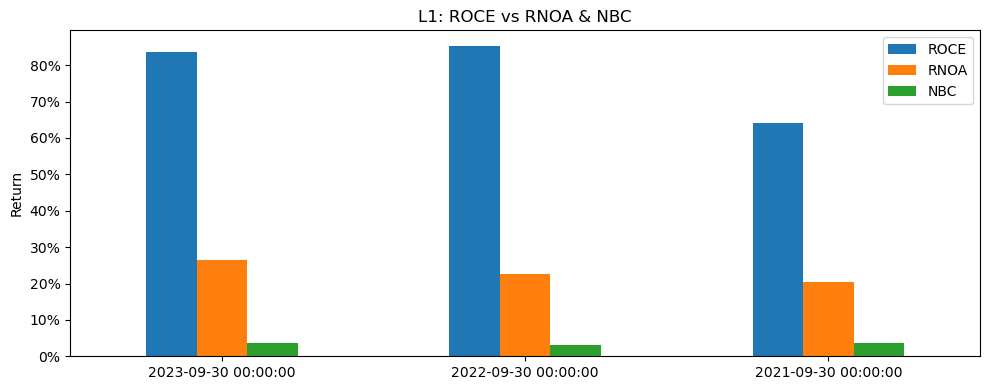

In [66]:
# 4a) Plot L1 bar chart
ax = l1[["ROCE","RNOA","NBC"]].plot(
    kind="bar", figsize=(10,4), rot=0
)
ax.set_title("L1: ROCE vs RNOA & NBC")
ax.set_ylabel("Return")
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
plt.tight_layout()
plt.show()

In [68]:
# 7/9/25
# 5) L2: RNOA = Margin × Turnover
nopat_margin = nopat / inc["Total Revenue"]
noa_turnover = inc["Total Revenue"] / noa

l2 = pd.DataFrame({
    "NOPAT Margin": nopat_margin,
    "NOA Turnover": noa_turnover,
    "RNOA":         nopat / noa
}).dropna()

print("\nL2 RNOA Decomposition:")
print(l2)


L2 RNOA Decomposition:
           NOPAT Margin NOA Turnover RNOA
2024-09-30         0.11         2.07 0.22
2023-09-30         0.12         2.26 0.26
2022-09-30         0.11         2.13 0.23
2021-09-30         0.13         1.63 0.20


In [ ]:
# 5a) Plot L2 bar chart
ax = l2[["NOPAT Margin","NOA Turnover"]].plot(
    kind="bar", figsize=(10,4), rot=0
)
ax.set_title("L2: NOPAT Margin & NOA Turnover")
plt.tight_layout()
plt.show()

In [ ]:
# === "6)" attempt #3 -> manual definition of sga first ===
# starting with list_columns to see all columns in income statement and balance sheet

list_columns(inc)  # to see all columns in income statement; focused on Selling General and Administrative (SG&A) expenses

# sga is 44 Selling General And Administration
list_columns(bs)  # to see all columns in balance sheet

In [ ]:
# === reattempting 6) / initial mapper exercise now that sga identified

# # ↪︎ 0) Map all the line items you’ll need
rev_col    = map_column(inc, "Total Revenue")
cogs_col   = map_column(inc, "Cost Of Revenue")             # could be in inc or bs

# sga_col    = map_column(bs,  "Selling General And Administration")
sga_col    = map_column(inc,  "Selling General And Administration")

recv_col   = map_column(bs,  "Receivables")
inv_col    = map_column(bs,  "Inventory")
pay_col    = map_column(bs,  "Payables And Accrued Expenses")
ppe_col    = map_column(bs,  "Net PPE")

In [71]:
# display the above mapped columns
print(f"\nMapped Columns:\nTotal Revenue: {rev_col}\nCost Of Revenue: {cogs_col}\nSelling General And Administration: {sga_col}\nReceivables: {recv_col}\nInventory: {inv_col}\nPayables And Accrued Expenses: {pay_col}\nNet PPE: {ppe_col}")


Mapped Columns:
Total Revenue: Total Revenue
Cost Of Revenue: Cost Of Revenue
Selling General And Administration: Selling General And Administration
Receivables: Receivables
Inventory: Inventory
Payables And Accrued Expenses: Payables And Accrued Expenses
Net PPE: Net PPE


In [78]:
# # 6) L3: Profitability & Activity Ratios (with mapped names)
l3 = pd.DataFrame({
    "COGS %":                   inc[cogs_col] / inc[rev_col],
    "SG&A %":                   inc[sga_col]  / inc[rev_col],
    "Days Sales Outs.":   (bs[recv_col]  / inc[rev_col]) * 365,
    "Days Inventory Outs.": (bs[inv_col]   / inc[cogs_col])   * 365,
    "Days Payables Outs.":  (bs[pay_col]   / inc[cogs_col])   * 365,
    "Fixed Asset Turnover":       inc[rev_col]   / bs[ppe_col].rolling(2).mean()
}).dropna()

print("\nL3 Decomposition Ratios:")
print(l3)


L3 Decomposition Ratios:
           COGS % SG&A % Days Sales Outs. Days Inventory Outs.  \
2023-09-30   0.73   0.07            12.01                25.23   
2022-09-30   0.74   0.06            13.30                33.27   
2021-09-30   0.71   0.07            14.23                28.32   

           Days Payables Outs. Fixed Asset Turnover  
2023-09-30               59.85                 2.13  
2022-09-30               62.79                 2.12  
2021-09-30               71.97                 1.99  


In [80]:
# (Optional) styled display in Jupyter

# if you just want the YYYY-MM-DD without time:
l3.index = l3.index.date

# or, if you only care about the YEAR:
# l3.index = l3.index.year.astype(str)

try:
    display(
      l3.style.format({
         "COGS %":"{:.1%}","SG&A %":"{:.1%}",
         "Days Sales Outstanding":"{:.0f}",
         "Days Inventory Outstanding":"{:.0f}",
         "Days Payables Outstanding":"{:.0f}",
         "Fixed Asset Turnover":"{:.2f}"
      })
    )
except:
    pass

,COGS %,SG&A %,Days Sales Outs.,Days Inventory Outs.,Days Payables Outs.,Fixed Asset Turnover
2023-09-30,72.6%,6.8%,12.013601,25.233492,59.845729,2.13
2022-09-30,74.0%,6.3%,13.303985,33.269917,62.790357,2.12
2021-09-30,71.1%,6.7%,14.231692,28.322924,71.973671,1.99


# 12JUL (SEMI-USELESS PLOTS V1)
- 📌 (NAMING / CONTENT TBD) Section 6: Implied vs Analyst Growth Plot
- 📌 (NAMING / CONTENT TBD) Section 7: Export Key Tables to Excel

In [ ]:
# 6b) Plot L3 bar chart
ax = l3[["COGS %","SG&A %"]].plot(
    kind="bar", figsize=(10,4), rot=0
)
ax.set_title("L3 Ratios: COGS % & SG&A %")
plt.tight_layout()
plt.show()

# 6c) Plot L3 bar chart - Just Turnover
ax = l3[["Fixed Asset Turnover"]].plot(
    kind="bar", figsize=(10,4), rot=0
)
ax.set_title("L3 Ratios: Fixed Asset Turnover")
plt.tight_layout()
plt.show()

In [ ]:
# # ## === ROE vs RNOA Plotting ===
# # == plots below largely useless as is unless refinements, additional context, or other enhancements are made ==
# # Assuming l1 and l2 DataFrames are already defined
# # Combine ROE and RNOA into a single DataFrame for plotting 
# core_df = pd.DataFrame({
#     "Fiscal Year": l2.index,
#     # "Fiscal Year": l1.index,
#     "ROE": l1["ROCE"],
#     "RNOA": l2["RNOA"]
# })


# core_df[["Fiscal Year", "ROE", "RNOA"]].set_index("Fiscal Year").plot(marker="o")
# plt.title("ROE vs RNOA")
# plt.ylabel("Return")
# plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
# plt.grid(True)
# plt.show();

In [82]:
# # line plots of all l1 ratios minus FLEV
# l1_plot = l1.drop(columns=["FLEV"])  # Drop FLEV for this plot
# l1_plot.plot(marker="o", figsize=(10, 6))
# plt.title("L1: ROCE Decomposition")
# plt.ylabel("Return")
# plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
# plt.grid(True)
# plt.tight_layout()
# plt.show();
# # line plots of all l2 ratios
# l2.plot(marker="o", figsize=(10, 6))
# plt.title("L2: RNOA Decomposition")
# plt.ylabel("Return")
# plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
# plt.grid(True)
# plt.tight_layout()
# plt.show();
# # line plots of l3 ratios
# l3.plot(marker="o", figsize=(10, 6))
# plt.title("L3: Profitability & Activity Ratios")
# plt.ylabel("Ratio")
# plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
# plt.grid(True)
# plt.tight_layout()
# plt.show();

In [83]:
# # line plots of l3 % ratios
# # Note: COGS % and SG&A % are in decimal format, so they will be plotted as such
# # If you want them in percentage format, you can multiply by 100 or use a formatter
# import matplotlib.ticker as mtick
# l3 = l3.copy()  # Create a copy to avoid modifying the original DataFrame
# # l3[["COGS %", "SG&A %"]] = l3[["COGS %", "SG&A %"]].apply(lambda x: x * 100)  # Convert to percentage

# # now plot them
# import matplotlib.pyplot as plt
# import matplotlib.ticker as mtick

# # Plotting the L3 ratios
# # cogs and sga % line plots
# l3[["COGS %", "SG&A %"]].plot(marker="o", figsize=(10, 6))
# plt.title("L3: COGS % & SG&A %")
# plt.ylabel("Percentage")
# # plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
# plt.grid(True)
# plt.tight_layout()
# plt.show();

# 16JUL INCOMPLETE VALUE BRIDGE PLOT

In [ ]:
# Begin plotting the value bridge or Implied vs Analyst comparison (GITHUB COPILOT 7/12/25, UNTESTED)
# import matplotlib.pyplot as plt
# # Define the data for the value bridge
# value_bridge_data = {
#     'Analyst Price Target': 95.0,
#     'Implied Value': total_value_new,
#     'Current Price': current_price
# }
# # Create a bar chart for the value bridge
# plt.figure(figsize=(10, 6))
# plt.bar(value_bridge_data.keys(), value_bridge_data.values(), color=['blue', 'green', 'orange'])
# plt.title('Value Bridge: Analyst Price Target vs Implied Value vs Current Price')
# plt.ylabel('Value ($)')
# plt.xticks(rotation=45)
# plt.axhline(y=current_price, color='red', linestyle='--', label='Current Price')
# plt.legend()
# plt.tight_layout()
# plt.show();

# Save the value bridge plot
# plt.savefig(f"{ticker}_value_bridge_{timestamp}.png")
# Save the value bridge plot
# plt.savefig(f"{ticker}_value_bridge_{current_date}.png")

# 21 July 2025: 
Agenda Breakdown [16 July 2025]
- ~~GITCOMMIT~~ 
- ~~CODE REBASE~~
- CODE CMP

Agenda Part 2: Remaining Plots Needed
- Revenue by Segment
- Implied Value vs Analyst Price Target & Value Bridge
- Sensitivity Analysis Matrix
- Historical Drivers
  1. ROCE vs RNOA Plotting
  2. ROE vs RNOA Plotting
  3. ROCE Decomposition Plotting
- [Placeholder for additional misc.]